In [71]:
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pickle
import warnings
warnings.filterwarnings('ignore')

with open('CustomerData.csv', 'r') as f:
    lines = [line.strip().strip('"') for line in f.readlines()]
 
# Create CSV string without the outer quotes
csv_string = '\n'.join(lines)
 
df = pd.read_csv(StringIO(csv_string))
print(df.head(50))


   ï»¿"CustomerID  Age Gender       City  AnnualIncome  TotalSpent  \
0            C001   28      F  Bangalore      450000.0      120000   
1            C002   35      M     Mumbai     1200000.0      850000   
2            C003   42      F      Delhi      300000.0       75000   
3            C004   26      M       Pune           NaN       40000   
4            C005   39      F  Bangalore      950000.0      600000   
5            C006   31      M    Chennai      520000.0      210000   
6            C007   47      F    Kolkata      280000.0       50000   
7            C008   29      F  Hyderabad      480000.0      190000   
8            C009   55      M     Mumbai     2000000.0     1500000   
9            C010   33      M  Bangalore      600000.0      250000   
10           C011   41      F      Delhi      350000.0       90000   
11           C012   24      M       Pune      220000.0       30000   
12           C013   38      F     Mumbai      800000.0      420000   
13           C014   

In [72]:
df.isnull().sum()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ï»¿"CustomerID         100 non-null    object 
 1   Age                    100 non-null    int64  
 2   Gender                 100 non-null    object 
 3   City                   100 non-null    object 
 4   AnnualIncome           99 non-null     float64
 5   TotalSpent             100 non-null    int64  
 6   MonthlyPurchases       100 non-null    int64  
 7   AvgOrderValue          100 non-null    int64  
 8   AppTimeMinutes         98 non-null     float64
 9   DiscountUsage          98 non-null     object 
 10  PreferredShoppingTime  99 non-null     object 
dtypes: float64(2), int64(4), object(5)
memory usage: 8.7+ KB


In [73]:
# Outlier Detection using IQR Method
print("Before Outlier Removal:")
print(f"Total Records: {len(df)}")
print(f"\nDataFrame Info:")
print(df[['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']].describe())


def remove_outliers_iqr(df, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_indices.extend(df[outliers].index.tolist())
        
        print(f"\n{col}:")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Outliers found: {outliers.sum()}")
    
    outlier_indices = list(set(outlier_indices))
    print(f"\nTotal unique outlier records: {len(outlier_indices)}")
    
    return df.drop(outlier_indices).reset_index(drop=True)


clustering_cols = [ 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']
df = remove_outliers_iqr(df, clustering_cols)

print(f"\nAfter Outlier Removal:")
print(f"Total Records: {len(df)}")
print(f"\nDataFrame Info:")
print(df[['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']].describe())

Before Outlier Removal:
Total Records: 100

DataFrame Info:
              Age  AnnualIncome    TotalSpent  MonthlyPurchases  \
count  100.000000  9.900000e+01  1.000000e+02        100.000000   
mean    38.260000  7.087879e+05  3.820000e+05          9.890000   
std     10.053011  4.270527e+05  3.619706e+05          5.899658   
min     22.000000  1.800000e+05  2.000000e+04          1.000000   
25%     29.750000  4.500000e+05  1.537500e+05          6.000000   
50%     37.000000  6.000000e+05  2.600000e+05          9.000000   
75%     46.000000  8.600000e+05  4.775000e+05         14.000000   
max     59.000000  2.200000e+06  1.700000e+06         24.000000   

       AvgOrderValue  AppTimeMinutes  
count     100.000000       98.000000  
mean     5345.500000       75.928571  
std      4555.111986       44.115418  
min      1000.000000        6.000000  
25%      2475.000000       48.500000  
50%      3100.000000       70.000000  
75%      6825.000000       95.000000  
max     19000.000000    

In [74]:

df['AnnualIncome'].fillna(df['AnnualIncome'].median(), inplace=True)
df['AppTimeMinutes'].fillna(df['AppTimeMinutes'].median(), inplace=True)

clustering_features = ['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']
X = df[clustering_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used for clustering:")
print(clustering_features)
print("\nFeature statistics after scaling:")
print(pd.DataFrame(X_scaled, columns=clustering_features).describe())


Features used for clustering:
['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']

Feature statistics after scaling:
                Age  AnnualIncome    TotalSpent  MonthlyPurchases  \
count  9.000000e+01  9.000000e+01  9.000000e+01      9.000000e+01   
mean   2.023073e-16 -1.307596e-16  6.908054e-17      1.184238e-16   
std    1.005602e+00  1.005602e+00  1.005602e+00      1.005602e+00   
min   -1.629591e+00 -1.611073e+00 -1.257532e+00     -1.619720e+00   
25%   -8.446960e-01 -5.928386e-01 -7.234502e-01     -7.709584e-01   
50%   -1.158654e-01 -1.370576e-01 -2.368422e-01      7.780314e-02   
75%    8.091889e-01  4.835804e-01  4.990039e-01      7.143743e-01   
max    2.407010e+00  2.733393e+00  2.920175e+00      2.199707e+00   

       AvgOrderValue  AppTimeMinutes  
count   9.000000e+01    9.000000e+01  
mean   -7.894919e-17    1.557396e-16  
std     1.005602e+00    1.005602e+00  
min    -1.087346e+00   -1.820767e+00  
25%    -6.308556e-01   -5

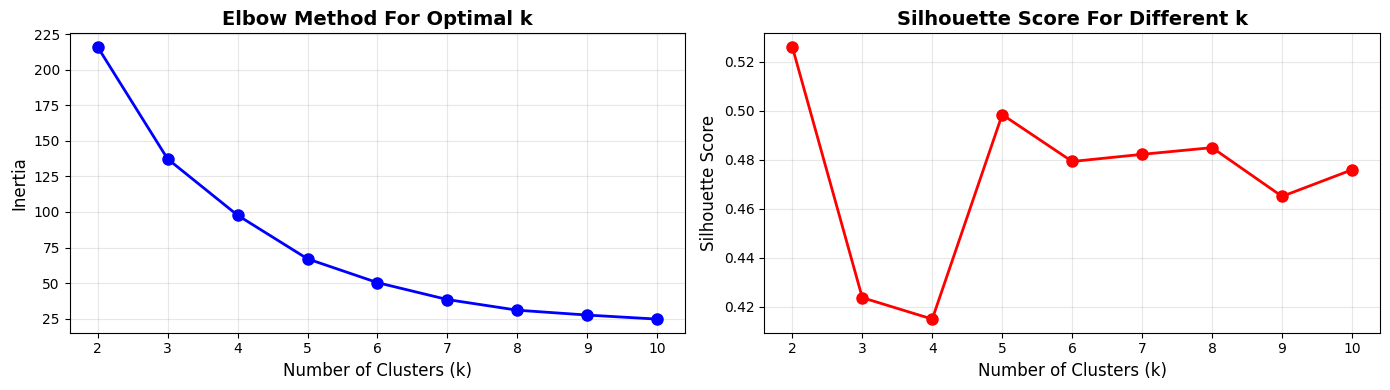

Silhouette Scores for different k values:
k=2: 0.5260
k=3: 0.4237
k=4: 0.4150
k=5: 0.4984
k=6: 0.4793
k=7: 0.4822
k=8: 0.4849
k=9: 0.4650
k=10: 0.4759


In [75]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method and Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score For Different k', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Silhouette Scores for different k values:")
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")


In [76]:
# Training K means with 3 clusters 
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"KMeans Model trained with k={optimal_k}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

cluster_segments = {
    0: "High-Value Loyal Customer",
    1: "Value-Seeking Regular Customer", 
    2: "Price-Sensitive Occasional Customer"
}

df['Segment'] = df['Cluster'].map(cluster_segments)
print("\nCluster Segments Mapping:")
for cluster, segment in cluster_segments.items():
    print(f"Cluster {cluster}: {segment}")



KMeans Model trained with k=3

Cluster distribution:
Cluster
0    32
1    41
2    17
Name: count, dtype: int64

Cluster Segments Mapping:
Cluster 0: High-Value Loyal Customer
Cluster 1: Value-Seeking Regular Customer
Cluster 2: Price-Sensitive Occasional Customer


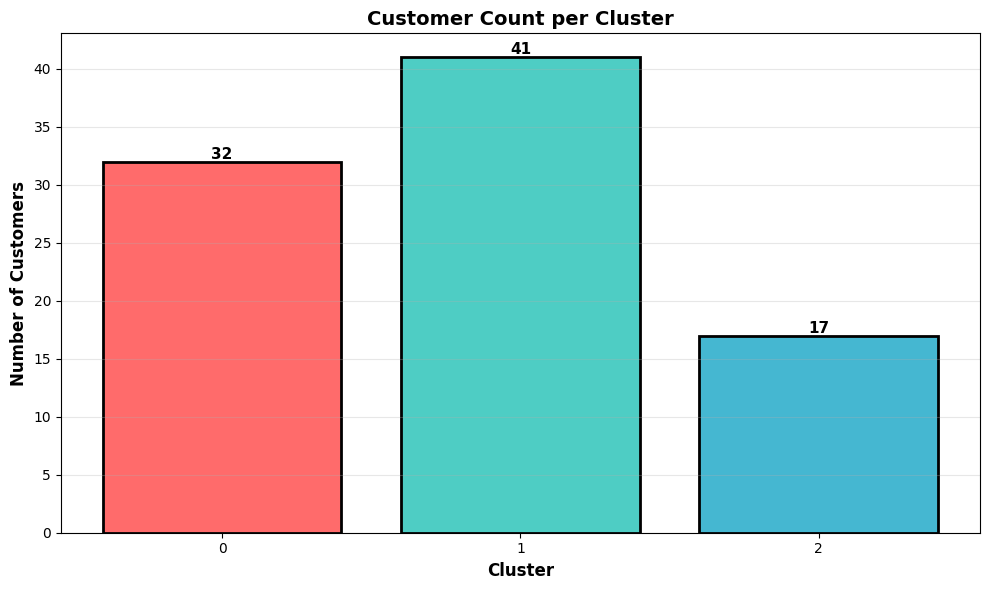

Cluster Size Distribution:
Cluster 0: 32 customers (35.6%)
Cluster 1: 41 customers (45.6%)
Cluster 2: 17 customers (18.9%)


In [77]:
# Visualization 1: Customer Count per Cluster
fig, ax = plt.subplots(figsize=(10, 6))
cluster_counts = df['Cluster'].value_counts().sort_index()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', linewidth=2)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_title('Customer Count per Cluster', fontsize=14, fontweight='bold')
ax.set_xticks(range(optimal_k))

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Cluster Size Distribution:")
for cluster in range(optimal_k):
    count = (df['Cluster'] == cluster).sum()
    percentage = (count / len(df)) * 100
    print(f"Cluster {cluster}: {count} customers ({percentage:.1f}%)")


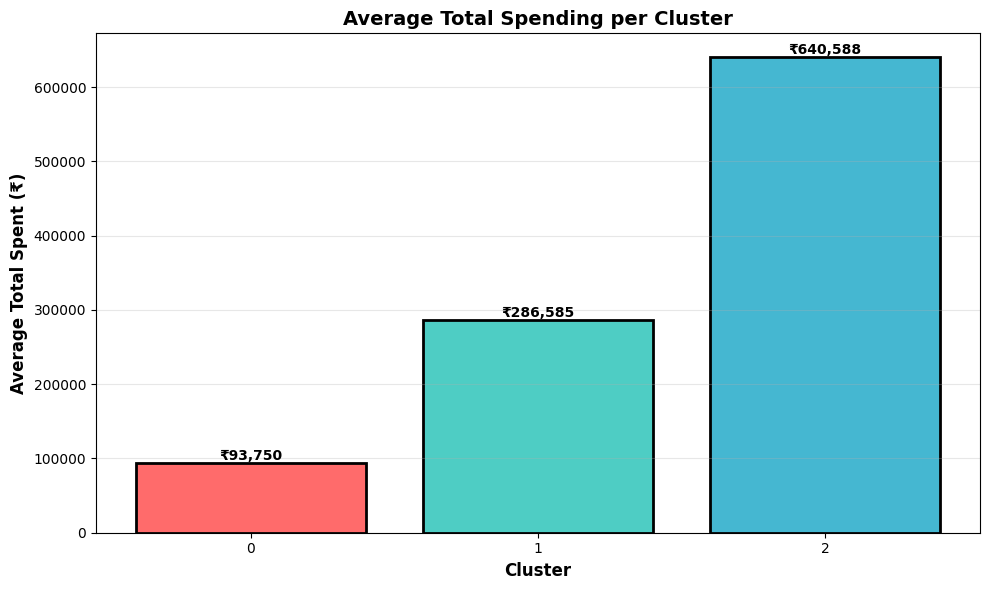

Average Spending by Cluster:
Cluster 0: ₹93,750.00
Cluster 1: ₹286,585.37
Cluster 2: ₹640,588.24


In [78]:
# Visualization 2: Average Spending per Cluster
fig, ax = plt.subplots(figsize=(10, 6))
avg_spending = df.groupby('Cluster')['TotalSpent'].mean()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(avg_spending.index, avg_spending.values, color=colors, edgecolor='black', linewidth=2)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Total Spent (₹)', fontsize=12, fontweight='bold')
ax.set_title('Average Total Spending per Cluster', fontsize=14, fontweight='bold')
ax.set_xticks(range(optimal_k))

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'₹{height:,.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Average Spending by Cluster:")
for cluster in range(optimal_k):
    avg_spend = df[df['Cluster'] == cluster]['TotalSpent'].mean()
    print(f"Cluster {cluster}: ₹{avg_spend:,.2f}")


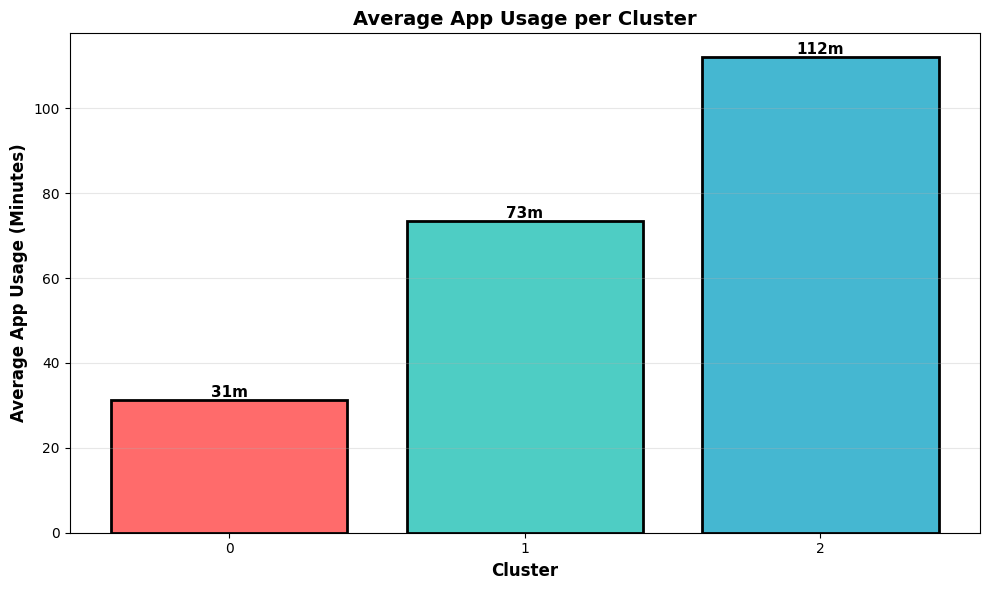

Average App Usage by Cluster:
Cluster 0: 31.3 minutes
Cluster 1: 73.4 minutes
Cluster 2: 112.1 minutes


In [79]:
# Visualization 3: Average App Usage per Cluster
fig, ax = plt.subplots(figsize=(10, 6))
avg_app_usage = df.groupby('Cluster')['AppTimeMinutes'].mean()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(avg_app_usage.index, avg_app_usage.values, color=colors, edgecolor='black', linewidth=2)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Average App Usage (Minutes)', fontsize=12, fontweight='bold')
ax.set_title('Average App Usage per Cluster', fontsize=14, fontweight='bold')
ax.set_xticks(range(optimal_k))

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}m',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Average App Usage by Cluster:")
for cluster in range(optimal_k):
    avg_usage = df[df['Cluster'] == cluster]['AppTimeMinutes'].mean()
    print(f"Cluster {cluster}: {avg_usage:.1f} minutes")


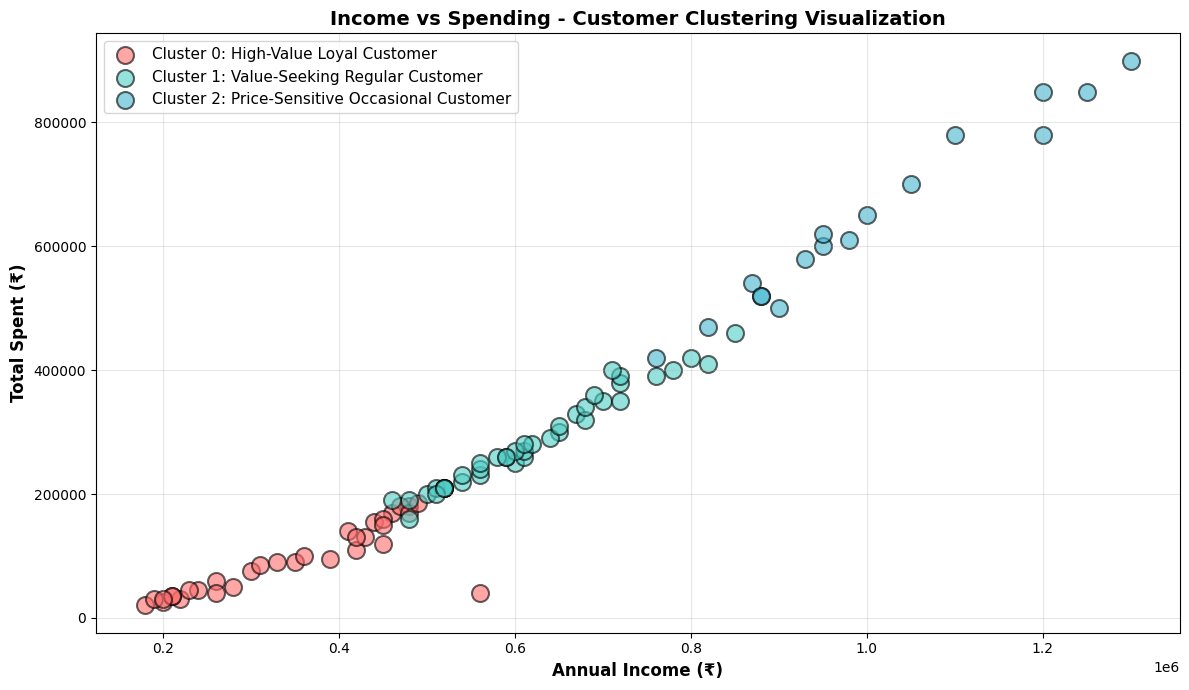

Cluster Profile Summary:

High-Value Loyal Customer (Cluster 0):
  Customer Count: 32
  Avg Annual Income: ₹347,812.50
  Avg Total Spent: ₹93,750.00
  Avg Monthly Purchases: 3.7
  Avg App Usage: 31.3 minutes
  Avg Order Value: ₹1,901.56

Value-Seeking Regular Customer (Cluster 1):
  Customer Count: 41
  Avg Annual Income: ₹620,243.90
  Avg Total Spent: ₹286,585.37
  Avg Monthly Purchases: 9.5
  Avg App Usage: 73.4 minutes
  Avg Order Value: ₹3,780.49

Price-Sensitive Occasional Customer (Cluster 2):
  Customer Count: 17
  Avg Annual Income: ₹1,001,176.47
  Avg Total Spent: ₹640,588.24
  Avg Monthly Purchases: 15.8
  Avg App Usage: 112.1 minutes
  Avg Order Value: ₹9,305.88


In [80]:
# Visualization 4: Income vs Spending - Scatter Plot with Cluster Separation
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    ax.scatter(cluster_data['AnnualIncome'], cluster_data['TotalSpent'], 
               s=150, alpha=0.6, label=f'Cluster {cluster}: {cluster_segments[cluster]}',
               color=colors[cluster], edgecolor='black', linewidth=1.5)

ax.set_xlabel('Annual Income (₹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Spent (₹)', fontsize=12, fontweight='bold')
ax.set_title('Income vs Spending - Customer Clustering Visualization', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cluster Profile Summary:")
print("=" * 80)
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\n{cluster_segments[cluster]} (Cluster {cluster}):")
    print(f"  Customer Count: {len(cluster_data)}")
    print(f"  Avg Annual Income: ₹{cluster_data['AnnualIncome'].mean():,.2f}")
    print(f"  Avg Total Spent: ₹{cluster_data['TotalSpent'].mean():,.2f}")
    print(f"  Avg Monthly Purchases: {cluster_data['MonthlyPurchases'].mean():.1f}")
    print(f"  Avg App Usage: {cluster_data['AppTimeMinutes'].mean():.1f} minutes")
    print(f"  Avg Order Value: ₹{cluster_data['AvgOrderValue'].mean():,.2f}")


In [81]:
# Save the trained KMeans model and scaler using pickle
model_path = 'kmeans_model.pkl'
scaler_path = 'scaler.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(kmeans, f)
print(f"KMeans model saved to '{model_path}'")

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to '{scaler_path}'")

segments_path = 'cluster_segments.pkl'
with open(segments_path, 'wb') as f:
    pickle.dump(cluster_segments, f)
print(f" Cluster segments mapping saved to '{segments_path}'")

csv_path = 'customer_clusters.csv'
df.to_csv(csv_path, index=False)
print(f"Customer data with clusters saved to '{csv_path}'")

print("\n" + "="*80)
print("All models and preprocessing objects saved successfully!")
print("Files created:")
print(f"  1. {model_path} - Trained KMeans model")
print(f"  2. {scaler_path} - StandardScaler for feature normalization")
print(f"  3. {segments_path} - Cluster to segment mapping")
print(f"  4. {csv_path} - Clustered customer data")


KMeans model saved to 'kmeans_model.pkl'
Scaler saved to 'scaler.pkl'
 Cluster segments mapping saved to 'cluster_segments.pkl'
Customer data with clusters saved to 'customer_clusters.csv'

All models and preprocessing objects saved successfully!
Files created:
  1. kmeans_model.pkl - Trained KMeans model
  2. scaler.pkl - StandardScaler for feature normalization
  3. cluster_segments.pkl - Cluster to segment mapping
  4. customer_clusters.csv - Clustered customer data
